In [2]:
import os
import sys
from pathlib import Path

import torch
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

torch.manual_seed(8008135)

NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

print("CODE_DIR:", CODE_DIR)
print("CODE_DIR contents:", os.listdir(CODE_DIR))

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device set to {device}")

if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

CODE_DIR: /home/daniel/HRM_Reconstruction/code
CODE_DIR contents: ['Utils', 'HRM_Model', 'Datasets', 'BiLSTM_Model', '.GPT2_Model[unused]', 'BERT_Model']
Device set to cuda


In [3]:
from Datasets.Sudoku_DataLoader import get_loaders

from BERT_Model.BERT_Sudoku import BERT_Baseline, BaselineConfig
from BERT_Model.BERT_Train import train_bert

from Datasets.Sudoku_DataLoader import collect_puzzles_set
from Utils.schedules import cosine_schedule_with_warmup_lr_lambda
from Utils.checkpointing import load_checkpoint
from Utils.visualization import show_sudoku_predictions, print_sudoku_comparison

/home/daniel/anaconda3/envs/HRM/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train_size = 2**21
test_size = 2**15
batch_size = 2**7

train_loader, val_loader = get_loaders(
    train_size=train_size,
    test_size=test_size,
    batch_size=batch_size,
)

Map: 100%|██████████| 32768/32768 [00:00<00:00, 41311.28 examples/s]


In [5]:
print("Collecting train puzzles...")
train_puzzles = collect_puzzles_set(train_loader)

print("Collecting val puzzles...")
val_puzzles = collect_puzzles_set(val_loader)

overlap = train_puzzles.intersection(val_puzzles)

print(f"\nTrain puzzles: {len(train_puzzles)}")
print(f"Val puzzles:   {len(val_puzzles)}")
print(f"Overlap:       {len(overlap)}")

if len(overlap) > 0:
    print("WARNING: Puzzle overlap detected!")
else:
    print("No puzzle overlap between train and validation sets.")


Train puzzles: 2097152
Val puzzles:   32768
Overlap:       0
No puzzle overlap between train and validation sets.


In [6]:
model_config = BaselineConfig(
    num_layers=12,
    num_heads=8,
    embedding_dim=512,
    vocab_size=10,
    block_size=81,
    dropout=0.2
)

lr = 1e-4
min_lr_ratio = 0.1 # -> 1e-5
lr_warmup = 0.05
beta1 = 0.9
beta2 = 0.95
weight_decay = 0.1
num_epochs = 10 # gives same num training steps as HRM with 2^18 training ex

checkpoint_dir = "checkpoints"

In [7]:
model = BERT_Baseline(model_config).to(device)

print(
    "Number of trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}",
)

Number of trainable parameters: 37,876,224


In [8]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=lr,
    betas=(beta1, beta2),
    weight_decay=weight_decay,
)

num_training_steps = len(train_loader) * num_epochs
num_warmup_steps = int(lr_warmup * num_training_steps)

scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda step: cosine_schedule_with_warmup_lr_lambda(
        step,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
        min_ratio=min_lr_ratio
    ),
)

print("num_training_steps:", num_training_steps)
print("num_warmup_steps:", num_warmup_steps)

num_training_steps: 163840
num_warmup_steps: 8192


In [9]:
model, best_metric, history = train_bert(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    device=device,
    scheduler=scheduler,
    num_epochs=num_epochs,
    checkpoint_dir=checkpoint_dir,
    checkpoint_every=5,
    validate_every=5,
    val_loader=val_loader,
    grad_clip=None,
    step_val_batches=1,
    step_val_every=8,
)
model.eval()

print("Best board accuracy used for checkpointing:", best_metric)

Number of trainable parameters: 37,876,224


Epoch 1: 100%|██████████| 16384/16384 [31:01<00:00,  8.80it/s]


Epoch 1: Avg Train Loss = 1.8904, Train Token Accuracy = 22.08%, Train Board Accuracy = 0.00%, LR = 9.94e-05


Epoch 2: 100%|██████████| 16384/16384 [30:51<00:00,  8.85it/s]


Epoch 2: Avg Train Loss = 1.0875, Train Token Accuracy = 50.09%, Train Board Accuracy = 1.09%, LR = 9.46e-05


...

Epoch 9: Avg Train Loss = 0.7123, Train Token Accuracy = 68.29%, Train Board Accuracy = 8.55%, LR = 1.24e-05


Epoch 10: 100%|██████████| 16384/16384 [30:58<00:00,  8.82it/s]


Epoch 10: Avg Train Loss = 0.7049, Train Token Accuracy = 68.63%, Train Board Accuracy = 9.12%, LR = 1.00e-05


Validation: 100%|██████████| 256/256 [00:09<00:00, 28.25it/s]


Val Loss = 0.6787, Val Token Accuracy = 70.37%, Val Board Accuracy = 12.72%

Best board accuracy used for checkpointing: 0.127166748046875


Weird thing here-- worth maybe another plot. 

While validation loss reaches a minimum and then increases (indicating overfitting), validation board accuracy still increases through that overfitting region

Because of this we actually choose our best model with a validation loss of 1.53 while there are models with it here as low as 0.84

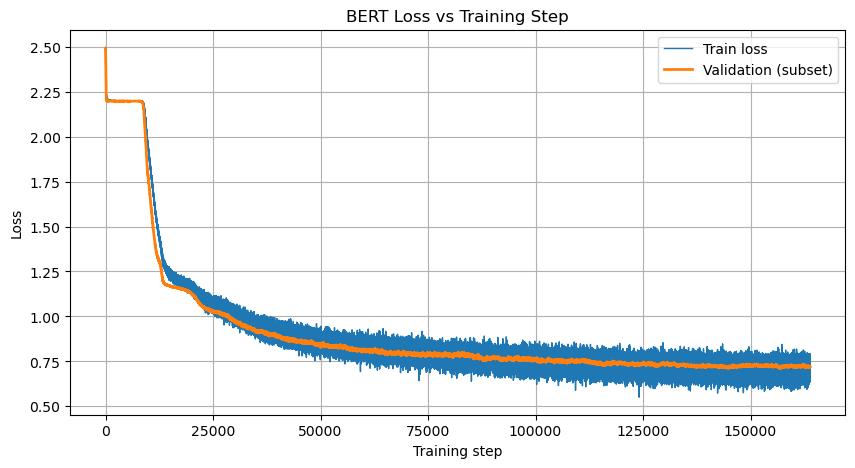

In [10]:
import matplotlib.pyplot as plt

train_steps = history["step"]
train_loss = history["train_loss"]

val_steps = [
    s for s, v in zip(history["step"], history["val_loss"])
    if v is not None
]

val_loss = [
    v for v in history["val_loss"]
    if v is not None
]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Train loss", linewidth=1)

if len(val_loss) > 0:
    plt.plot(val_steps, val_loss, label="Validation (subset)", linewidth=2)

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("BERT Loss vs Training Step")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
show_sudoku_predictions(
    model,
    val_loader,
    device,
)

Input / Prediction
8 9 4 | 6 6 1 | 2 5 3 
7 3 1 | 5 2 8 | 4 9 6 
2 6 2 | 4 7 7 | 3 8 1 
---------------------------------
8 7 9 | 3 6 2 | 1 4 5 
1 2 6 | 1 5 4 | 7 3 9 
4 5 3 | 1 7 7 | 8 6 2 
---------------------------------
5 1 5 | 9 4 3 | 6 2 7 
3 4 2 | 7 8 5 | 6 1 9 
9 8 7 | 2 1 6 | 9 1 4 

Unknown-cell token accuracy: 0.6111111044883728

Input / Prediction
2 9 2 | 4 5 6 | 1 8 3 
3 5 7 | 2 8 1 | 9 6 7 
4 6 1 | 7 9 3 | 2 4 5 
---------------------------------
9 3 4 | 6 2 5 | 7 1 8 
5 1 2 | 8 7 4 | 6 3 9 
6 1 6 | 1 3 9 | 4 5 2 
---------------------------------
7 8 7 | 5 1 2 | 3 9 4 
1 4 9 | 3 3 7 | 8 2 6 
6 2 3 | 9 4 8 | 5 7 1 

Unknown-cell token accuracy: 0.7962962985038757

Input / Prediction
5 2 9 | 7 6 8 | 3 4 1 
5 6 7 | 9 1 4 | 2 8 5 
1 4 8 | 5 2 3 | 9 6 7 
---------------------------------
4 3 5 | 6 8 1 | 7 2 9 
2 9 2 | 3 4 5 | 7 1 6 
7 1 6 | 8 9 2 | 4 5 3 
---------------------------------
9 8 4 | 1 3 6 | 5 7 2 
6 7 4 | 4 5 9 | 1 3 2 
3 5 1 | 2 8 7 | 6 9 8 

Unknown-cell toke